# Imports

In [39]:
from sunpy.net import Fido
from sunpy.net import attrs as a
from sunpy.timeseries import TimeSeries 
from sunpy.timeseries import GenericTimeSeries
from sunpy.time import parse_time
from sunpy.data import cache
from sunpy.coordinates import spice, frames
from sunpy.coordinates import get_horizons_coord, get_body_heliographic_stonyhurst

from astropy import units as u
from astropy.time import Time

import matplotlib.pyplot as plt
import numpy as np 

import os
import urllib.request

import pandas as pd
import datetime as dt

from scipy.stats import norm
import seaborn as sns

import polars as pl

from kneed import KneeLocator, DataGenerator
from kneed import find_shape
from scipy import stats

# uncomment line below to see what datasets are available to query from the CDAWeb
# a.cdaweb.Dataset('OMNI_HRO2_1MIN')#wi_k0_swe # WI_K0_SWE https://cdaweb.gsfc.nasa.gov/misc/NotesW.html#WI_K0_SWE

In [40]:
import warnings
warnings.filterwarnings("ignore")

# Functions

In [41]:
#Find DateRanges for each file needed found
def ReadDates(startDate, endDate): #ReadDatesForFileFinding
    DateRange = pd.date_range(startDate, endDate, freq='MS').strftime("%Y%m%d").tolist()
    return DateRange

# Get to date portion of the file names
def myFunc(e):
  return e.split("b")[1]

# Get the pre-downloaded data from folder
def FindData(directory, dataName, startDate, endDate): #FindDataMakeTimeSeries
    files = []
    for file in os.listdir(directory):
        filename = os.fsdecode(file)
        DateRange = ReadDates(startDate, endDate)
        for j in range(len(DateRange)):
            if filename.startswith(dataName + str(DateRange[j])[0:6]):
                files.append(directory+filename)
                continue
    filesSorted = sorted(files, key=myFunc) # sort files
    df_list = [] #pd.DataFrame([])
    # Columns from https://omniweb.gsfc.nasa.gov/html/HROdocum.html
    colnames = ["Year", "DOY", "Hour", "Minute", "IMF_PTS", "PercentInterp", "CP/MVFlag", "Timeshift", "PFN_XGSE", "PFN_YGSE","PFN_ZGSE", "ScalarB", "Bx_GSEGSM", "ByGSE", "BzGSE", "ByGSM", "BzGSM", "RMSTimeshift", "RMS_PFN", "RMSScalarB", "RMSFieldVector", "Plasma_PTS", "FlowSpeed", "Vx_GSE", "Vy_GSE", "Vz_GSE", "ProtonDensity", "Temp", "X_s_c_GSE", "Y_s_c_GSE", "Z_s_c_GSE", "X_targ_GSE", "Y_targ_GSE", "Z_targ_GSE", "RMS_targ", "DBOT1", "DBOT2"]
    for j in range(len(filesSorted)):
        df_list.append( pd.read_csv(filesSorted[j], header=None, sep = "\s+", names = colnames) )
    dataTimeSeries = pd.concat(df_list, ignore_index=True)

    # replace with nans
    WindFillerVals = [999, 9.9, 999999, 99.99, 9999.99, 99999.9, 999.99, 9999999] #https://omniweb.gsfc.nasa.gov/html/HROdocum.html#4b
    dataTimeSeriesFillersToNans = dataTimeSeries.replace(WindFillerVals, np.nan)

    return dataTimeSeriesFillersToNans


# # Get the pre-downloaded data from folder - Started to try and make the code easy to switch between wind/omni but later code will face issues as colnames are different so left for now
# def FindData(DataName, startDate, endDate): #FindDataMakeTimeSeries
#     if DataName == "Wind":
#         directory = "Data/windData/"
#         dataName = "wind_min_b" # b = shifted to bow shock nose (by technique 4)
#         files = []
#         for file in os.listdir(directory):
#             filename = os.fsdecode(file)
#             DateRange = ReadDates(startDate, endDate)
#             for j in range(len(DateRange)):
#                 if filename.startswith(dataName + str(DateRange[j])[0:6]):
#                     files.append(directory+filename)
#                     continue
#         filesSorted = sorted(files, key=myFunc) # sort files
#         df_list = [] #pd.DataFrame([])
#         # Columns from https://omniweb.gsfc.nasa.gov/html/HROdocum.html
#         colnames = ["Year", "DOY", "Hour", "Minute", "IMF_PTS", "PercentInterp", "CP/MVFlag", "Timeshift", "PFN_XGSE", "PFN_YGSE","PFN_ZGSE", "ScalarB", "Bx_GSEGSM", "ByGSE", "BzGSE", "ByGSM", "BzGSM", "RMSTimeshift", "RMS_PFN", "RMSScalarB", "RMSFieldVector", "Plasma_PTS", "FlowSpeed", "Vx_GSE", "Vy_GSE", "Vz_GSE", "ProtonDensity", "Temp", "X_s_c_GSE", "Y_s_c_GSE", "Z_s_c_GSE", "X_targ_GSE", "Y_targ_GSE", "Z_targ_GSE", "RMS_targ", "DBOT1", "DBOT2"]
#         for j in range(len(filesSorted)):
#             df_list.append( pd.read_csv(filesSorted[j], header=None, sep = "\s+", names = colnames) )
#         dataTimeSeries = pd.concat(df_list, ignore_index=True)

#         # replace with nans
#         WindFillerVals = [999, 9.9, 999999, 99.99, 9999.99, 99999.9, 999.99, 9999999] #https://omniweb.gsfc.nasa.gov/html/HROdocum.html#4b
#         dataTimeSeriesFillersToNans = dataTimeSeries.replace(WindFillerVals, np.nan)
#     elif DataName == "Omni":
#         directory = "./Data/omniData/"
#         dataName = "omni_hro2_1min_"
#         files = []
#         for file in os.listdir(directory):
#             filename = os.fsdecode(file)
#             DateRange = ReadDates(startDate, endDate)
#             for j in range(len(DateRange)):
#                 if filename.startswith(dataName + str(DateRange[j])):
#                     files.append(directory+filename)
#                     continue
#         filesSorted = sorted(files, key=myFunc) # sort files
#         dataTimeSeries = TimeSeries(filesSorted, concatenate=True)

#         # replace with nans
#         OmniFillerVals = [99, 999, 999999, 99.99, 9999.99, 99999.9, 999.99, 999.9, 99999, 9.999, 99.9, 99999.99] #https://omniweb.gsfc.nasa.gov/html/HROdocum.html#4b
#         dataTimeSeriesFillersToNans = dataTimeSeries.replace(OmniFillerVals, np.nan)
#     else: 
#         print("Named data not available.")

#     return dataTimeSeriesFillersToNans

# Calculate Total Vsw
def AddTotVsw(dataTimeSeries):
    TotVsw = np.sqrt(dataTimeSeries._data["Vx_GSE"]**2 + 
                     dataTimeSeries._data["Vy_GSE"]**2 + 
                     dataTimeSeries._data["Vz_GSE"]**2)
    dataTimeSeries = dataTimeSeries.add_column("TotVsw", TotVsw)
    return dataTimeSeries

#Plot Vsw
def PlotVsw(dataTimeSeries):
    # dataTimeSeries[cols] = dataTimeSeries[dataTimeSeries[cols] > filter][cols]
    fig, ax = plt.subplots()
    dataTimeSeries.plot(columns=["TotVsw", "Vx_GSE", "Vy_GSE", "Vz_GSE"], alpha = 0.5)
    plt.legend(loc="upper right")
    # plt.ylim(-450,900)
    # print(dataTSFirstDates._data[""].unique())

# Combine the components of magnetic field from data to get magnitude of magnetic field, BMag
def AddBMag(dataTimeSeries):
    BMag = np.sqrt(dataTimeSeries._data["Bx_GSEGSM"]**2 + 
                   dataTimeSeries._data["ByGSE"]**2 + 
                   dataTimeSeries._data["BzGSE"]**2)
    dataTimeSeries = dataTimeSeries.add_column("BMag", BMag)
    return dataTimeSeries

#Plot B
def PlotB(dataTimeSeries):
    fig, ax = plt.subplots()
    dataTimeSeries.plot(columns=["BMag", "Bx_GSEGSM", "ByGSE", "BzGSE"], alpha = 0.5)
    plt.legend(loc="upper right")
    # plt.ylim(-40,90)
    # print(dataTSFirstDates._data[""].unique())

# Dotted plots
def PlotVswDotted(dataTimeSeries):
    fig, ax  = plt.subplots(4, sharex=True, figsize=(10, 10))
    # total Wind speed
    dataTimeSeries._data["TotVsw"].plot(ax=ax[0], marker='.', ls='', ms=1)
    ax[0].set_ylabel("Tot V$_{SW}$ (km/s)")
    # # flow speed
    # dataTimeSeries._data["FlowSpeed"].plot(ax=ax[1], marker='.', ls='', ms=1)
    # ax[1].set_ylabel("Flow speed (km/s)")
    # components of Wind speed, Vx
    dataTimeSeries._data["Vx_GSE"].plot(ax=ax[1], marker='.', ls='', ms=1) # this is getting negative results, which makes sense if V_GSM_0 is the X GSM axis (towards the Sun) since the SW will be flowing in the opposite direction.
    ax[1].set_ylabel("Vx V$_{SW}$ (km/s)")
    # components of Wind speed, Vy
    dataTimeSeries._data["Vy_GSE"].plot(ax=ax[2], marker='.', ls='', ms=1) # this is likely Y then (essentially along the west->east line of the (center of the) Earth).
    ax[2].set_ylabel("Vy V$_{SW}$ (km/s)")
    # components of Wind speed, Vz
    dataTimeSeries._data["Vz_GSE"].plot(ax=ax[3], marker='.', ls='', ms=1) # and this is likely Z then (essentially along the south->north line of the (center of the) Earth).  I guess you'd expect these components to be lower than the radial one as the solar OMNI is mostly radial/along the Parker spiral
    ax[3].set_ylabel("Vz V$_{SW}$ (km/s)")

    for aa in ax:
        aa.legend(loc="upper left")
        # aa.axvline("2022-01-29 00:00", color='k')
        # aa.axvline("2022-01-30 02:00", color='k', ls="dashed")
        # aa.set_ylim(-400,400)

    # ax[4].set_xlabel("Time")
    plt.tight_layout()
    plt.subplots_adjust(hspace=0.02)

# Plot histograms all together
def PlotHistTogether(dataTimeSerieses, VarsToPlot):
    for i in range(len(VarsToPlot)):
        for j in range(len(dataTimeSerieses)):
            plt.hist(dataTimeSerieses[j]._data[VarsToPlot[i]], bins = Bin, label = "Wind " + str(StartAndEnd[j][0] + " - " + str(StartAndEnd[j][1])), alpha = Alpha, density = True)
        plt.title("Solar Wind " + VarsToPlot[i])
        plt.xlabel(VarsToPlot[i] + r", GSE, $km/s$")
        plt.legend(fontsize=Legend)
        plt.show()

#Plot histograms separately
def PlotHistSeparate(dataTimeSerieses, VarsToPlot):
    for i in range(len(VarsToPlot)): # For each variable
        LowerBounds = [] # set lower bounds array to 0
        UpperBounds = [] # set upper bounds array to 0
        fig, axs = plt.subplots(4,1, figsize=FigSize, sharex=True)
        fig.subplots_adjust(hspace=0)
        for j in range(len(dataTimeSerieses)): # For each daterange
            axs[j].hist(dataTimeSerieses[j]._data[VarsToPlot[i]], bins = Bin, label = "Wind " + str(StartAndEnd[j][0]) + " - " + str(StartAndEnd[j][1]), color=Colours[j], alpha = Alpha, density = True)
            #Mean
            axs[j].axvline(dataTimeSerieses[j]._data[VarsToPlot[i]].mean(), linestyle = '--', color = "grey", label="mean = " + str(dataTimeSerieses[j]._data[VarsToPlot[i]].mean()))
            #Median
            axs[j].axvline(dataTimeSerieses[j]._data[VarsToPlot[i]].median(), linestyle = '--', color = "black", label="median = " + str(dataTimeSerieses[j]._data[VarsToPlot[i]].median()))
            #Standard deviation
            axs[j].axvline(dataTimeSerieses[j]._data[VarsToPlot[i]].std(), color = "grey", label="std dev = " + str(dataTimeSerieses[j]._data[VarsToPlot[i]].std()), alpha = 0)

            axs[j].legend(loc = LegLoc, fontsize = Legend)
                # axs[1].legend(loc = LegLoc, fontsize = Legend)
                # axs[2].legend(loc = LegLoc, fontsize = Legend)
                # axs[3].legend(loc = LegLoc, fontsize = Legend)
            
            LowerBounds.append(min(dataTimeSerieses[j]._data[VarsToPlot[i]].values))
            UpperBounds.append(max(dataTimeSerieses[j]._data[VarsToPlot[i]].values))
            # LowerBounds.append(min(dataTimeSerieses[j]._data[Plotting[i]].values))
            # UpperBounds.append(max(dataTimeSerieses[j]._data[Plotting[i]].values))
            # LowerBounds.append(min(dataTimeSerieses[j]._data[Plotting[i]].values))
            # UpperBounds.append(max(dataTimeSerieses[j]._data[Plotting[i]].values))
            # LowerBounds.append(min(dataTimeSerieses[j]._data[Plotting[i]].values))
            # UpperBounds.append(max(dataTimeSerieses[j]._data[Plotting[i]].values))
        
        plt.suptitle("Solar Wind "+ VarsToPlot[i] + ", ", fontsize = SupTitle)
        fig.supxlabel(VarsToPlot[i] + ", " + str(Units[i]))

        plt.xlim(min(LowerBounds) - SpaceLR[i], max(UpperBounds) + SpaceLR[i])
        plt.savefig("Plots/Wind/" + StartAndEnd[0][0][0:10] + "->" + StartAndEnd[0][0][0:10] + VarsToPlot[i] + "_Wind.png")
        # plt.show()

# Plot CDF
def PlotCDF(dataTimeSerieses, VarsToPlot):
    # fig, axs = plt.subplots()#4,1, figsize=FigSize, sharex=True)
    # fig.subplots_adjust(hspace=0)
    for i in range(len(VarsToPlot)):
        for j in range(len(dataTimeSerieses)):
            sns.ecdfplot(dataTimeSerieses[j]._data[VarsToPlot[i]], label="Wind " + str(StartAndEnd[j][0]) + " - " + str(StartAndEnd[j][1]), color=Colours[j])
        plt.xlabel(VarsToPlot[i] + ", " + Units[i])
        plt.ylabel('Cumulative probability')
        plt.ylim(yLim)
        plt.legend(fontsize=Legend)
        plt.grid(True)
        plt.savefig("Plots/Wind/" + StartAndEnd[0][0][0:10] + "->" + StartAndEnd[0][0][0:10] + VarsToPlot[i] + "_CDF_Wind.png") #  + dataTimeSerieses[0] + " - " + dataTimeSerieses[-1] 
        plt.show()

## Plot DQQs
# Calculate quantiles
def get_quantiles(
    x: pl.Series,
    y: pl.Series,
    size: int = 500, # 500 data points to calculate (default)
    p_range: Tuple[float, float] = (0.0001, 0.9999),) -> Tuple[NDArray, NDArray]: # p_range default set to values used in Tindale and Chapman 2017 to recreate their plots

    x_sorted = np.sort(x.drop_nulls().drop_nans().to_numpy()) # Sort data
    y_sorted = np.sort(y.drop_nulls().drop_nans().to_numpy()) # Sort data

    probabilities = np.linspace(*p_range, size) # make linspace of probabilities in range

    x_quantiles = np.quantile(x_sorted, probabilities) # calculate the quantiles
    y_quantiles = np.quantile(y_sorted, probabilities) # calculate the quantiles

    return x_quantiles, y_quantiles

## Simple FindKnee function without breakpoint finding
# def FindKnee(x, y):
#     direction, curve = find_shape(x, y)
#     kl = KneeLocator(x, y, curve=curve, direction=direction)
#     xOfKnee = kl.knee
#     yOfKnee = kl.knee_y
#     return xOfKnee, yOfKnee

# FindKnee function with breakpoint finding
def FindQuantOfKnee(x, y):
    direction, curve = find_shape(x, y)
    xlen = len(x)
    ylen = len(y)
    print(xlen, ylen)
    # kl = KneeLocator(x[int(xlen/2):-1], y[int(ylen/2):-1], curve=curve, direction=direction)
    kl = KneeLocator(x, y, curve=curve, direction=direction)
    xOfKnee = kl.knee
    yOfKnee = kl.knee_y
    print(xOfKnee, yOfKnee)
    
    XRes = stats.ecdf(x)#(xOfKnee)
    YRes = stats.ecdf(y)
    # print(Strawb.cdf.quantiles[4000])
    FindXidx = np.where(XRes.cdf.quantiles == xOfKnee)
    FindYidx = np.where(YRes.cdf.quantiles == yOfKnee)
    print(FindXidx, FindYidx)

    FindXidx = FindXidx[0][0]
    FindYidx = FindYidx[0][0]

    if FindXidx == FindYidx:
        ProbValue = XRes.cdf.probabilities[FindXidx]
        print(XRes.cdf.probabilities[FindXidx])
        print(YRes.cdf.probabilities[FindYidx])

    else:
        print("Indexes don't match")
        print(FindXidx, FindYidx)
        print(XRes.cdf.quantiles[FindXidx])
        print(YRes.cdf.quantiles[FindYidx])
        print("XRes -1")
        print(XRes.cdf.quantiles[FindXidx-1])
        print("YRes -1")
        print(YRes.cdf.quantiles[FindYidx-1])
        # ProbValue = XRes.cdf.probabilities[FindXidx]
        # ProbValue = YRes.cdf.probabilities[FindYidx]
        ProbValue = np.nan

    quantOfKnee = ProbValue
    return xOfKnee, yOfKnee, quantOfKnee

#Plot DQQ graphs with qs
def PlotDQQ(dataTimeSeriesToCompare, VarsToPlot, QuantilesSpecific):
    for i in range(len(VarsToPlot)): # do each parameter
        fig, ax  = plt.subplots(figsize=(5, 5))
        for j in range(len(dataTimeSeriesToCompare)): # do each comparison
            dataTimeSeriesPS1 = pl.Series(dataTimeSeriesToCompare[j][0]._data[VarsToPlot[i]])
            dataTimeSeriesPS2 = pl.Series(dataTimeSeriesToCompare[j][1]._data[VarsToPlot[i]])
            xQuant, yQuant = get_quantiles(dataTimeSeriesPS1, dataTimeSeriesPS2, size = 5000, p_range=(0.0001, 0.9999))
            plt.scatter(xQuant, yQuant, color=Color[j], s=2, label = PlotLabels[j])

            xOfKnee, yOfKnee, quantOfKnee = FindQuantOfKnee(xQuant, yQuant)

            if np.isnan(quantOfKnee):
                print("---------------------------")
                print("Error finding breakpoints q")
                print("---------------------------")
            else:
                plt.plot(xOfKnee, yOfKnee, "o", color="black", label = "q = " + str(quantOfKnee))
            # plt.plot(xOfKnee, yOfKnee, "o", color="black")
        
        x = np.linspace(-100, 900, 2)
        y = x
        plt.plot(x, y, color="grey")
        plt.title("T&C 2017 Fig 4aiii)")
        plt.legend(loc="lower right", fontsize = Legend)
        plt.xlabel(VarsToPlot[i] + r", $km/s$, solar min.")
        plt.ylabel(VarsToPlot[i] + r", $km/s$, solar max.")
        plt.xlim(Lims[i]) #min(xQuantC23)-np.absolute(min(xQuantC23)/2) , max(xQuantC23)+np.absolute(max(xQuantC23)/2))
        plt.ylim(Lims[i]) #min(xQuantC23)-np.absolute(min(xQuantC23)/2), max(xQuantC23)+np.absolute(max(xQuantC23)/2))
        plt.savefig("DQQ_Wind.png")

        plt.show()

# Wind data

## Date ranges

In [42]:
# Cycle 23 Min # 1 Dec 95 - 30 Nov 96 as Cycle 23 min
startDateC23Min = "1995-12-01 00:00"
endDateC23Min = "1996-11-30 23:59"

# Cycle 23 Max # 1 Oct 99 - 30 Sept 00 as Cycle 23 max
startDateC23Max = "1999-10-01 00:00"
endDateC23Max = "2000-09-30 23:59"

# Cycle 24 Min # 1 Aug 07 - 31 July 08 as Cycle 24 min
startDateC24Min = "2007-08-01 00:00"
endDateC24Min = "2008-07-31 23:59"

# Cycle 24 Max # 1 Nov 13 - 31 Oct 14 as Cycle 24 max
startDateC24Max = "2013-11-01 00:00"
endDateC24Max = "2014-10-31 23:59"

DateRangeC23Min = ReadDates(startDateC23Min, endDateC23Min)
print(DateRangeC23Min)
DateRangeC23Max = ReadDates(startDateC23Max, endDateC23Max)
print(DateRangeC23Max)
DateRangeC24Min = ReadDates(startDateC24Min, endDateC24Min)
print(DateRangeC24Min)
DateRangeC24Max = ReadDates(startDateC24Max, endDateC24Max)
print(DateRangeC24Max)

['19951201', '19960101', '19960201', '19960301', '19960401', '19960501', '19960601', '19960701', '19960801', '19960901', '19961001', '19961101']
['19991001', '19991101', '19991201', '20000101', '20000201', '20000301', '20000401', '20000501', '20000601', '20000701', '20000801', '20000901']
['20070801', '20070901', '20071001', '20071101', '20071201', '20080101', '20080201', '20080301', '20080401', '20080501', '20080601', '20080701']
['20131101', '20131201', '20140101', '20140201', '20140301', '20140401', '20140501', '20140601', '20140701', '20140801', '20140901', '20141001']


## Find data in files

In [43]:
# # Get the pre-downloaded data from folder
# def FindData(directory, dataName, startDate, endDate): #FindDataMakeTimeSeries
#     files = []
#     for file in os.listdir(directory):
#         filename = os.fsdecode(file)
#         DateRange = ReadDates(startDate, endDate)
#         for j in range(len(DateRange)):
#             if filename.startswith(dataName + str(DateRange[j])[0:6]):
#                 files.append(directory+filename)
#                 continue
#     filesSorted = sorted(files, key=myFunc) # sort files
#     print(files)
#     print(myFunc(files[0]))
#     print(filesSorted)
#     df_list = [] #pd.DataFrame([])
#     # Columns from https://omniweb.gsfc.nasa.gov/html/HROdocum.html
#     colnames = ["Year", "DOY", "Hour", "Minute", "IMF_PTS", "PercentInterp", "CP/MVFlag", "Timeshift", "PFN_XGSE", "PFN_YGSE","PFN_ZGSE", "ScalarB", "Bx_GSEGSM", "ByGSE", "BzGSE", "ByGSM", "BzGSM", "RMSTimeshift", "RMS_PFN", "RMSScalarB", "RMSFieldVector", "Plasma_PTS", "FlowSpeed", "Vx_GSE", "Vy_GSE", "Vz_GSE", "ProtonDensity", "Temp", "X_s_c_GSE", "Y_s_c_GSE", "Z_s_c_GSE", "X_targ_GSE", "Y_targ_GSE", "Z_targ_GSE", "RMS_targ", "DBOT1", "DBOT2"]
#     for j in range(len(filesSorted)):
#         df_list.append( pd.read_csv(filesSorted[j], header=None, sep = "\s+", names = colnames) )
#         # df2 = pd.read_csv(filesSorted[j+1], sep=" ")
#         # pd.concat([df1, df2])
#     print(df_list)
#     dataTimeSeries = pd.concat(df_list, ignore_index=True)

#     # dataTimeSeries = TimeSeries(filesSorted, concatenate=True)

#     return dataTimeSeries

In [44]:
directory = "Data/windData/"
dataName = "wind_min_b" # b = shifted to bow shock nose (by technique 4)

# DataFrame = FindData(directory, dataName, FAKEstartDateC23Min, FAKEendDateC23Min)
dataTSFirstDatesC23Min = FindData(directory, dataName, startDateC23Min, endDateC23Min)
dataTSFirstDatesC23Max = FindData(directory, dataName, startDateC23Max, endDateC23Max)
dataTSFirstDatesC24Min = FindData(directory, dataName, startDateC24Min, endDateC24Min)
dataTSFirstDatesC24Max = FindData(directory, dataName, startDateC24Max, endDateC24Max)

# Columns from https://omniweb.gsfc.nasa.gov/html/HROdocum.html

In [45]:
# print(dataTSFirstDatesC23Min.head())
# ts = DataFrame.set_index('Year') 
# print(ts.head())

def dfToSeries(DataFrame):
    DataFrame.insert(0, "DateTime", pd.to_datetime(DataFrame['Year'] * 10000000 + DataFrame['DOY']*10000 + DataFrame['Hour']*100 + DataFrame['Minute'], format='%Y%j%H%M'))
    DataFrameDateTimeIndex = DataFrame.set_index('DateTime') 

    # colnames = ["Year", "DOY", "Hour", "Minute", "IMF_PTS", "PercentInterp", "CP/MVFlag", "Timeshift", "PFN_XGSE", "PFN_YGSE","PFN_ZGSE", "ScalarB", "Bx_GSEGSM", "ByGSE", "BzGSE", "ByGSM", "BzGSM", "RMSTimeshift", "RMS_PFN", "RMSScalarB", "RMSFieldVector", "Plasma_PTS", "FlowSpeed", "Vx_GSE", "Vy_GSE", "Vz_GSE", "ProtonDensity", "Temp", "X_s_c_GSE", "Y_s_c_GSE", "Z_s_c_GSE", "X_targ_GSE", "Y_targ_GSE", "Z_targ_GSE", "RMS_targ", "DBOT1", "DBOT2"]
    SunpyTimeSeries =  GenericTimeSeries(DataFrameDateTimeIndex)
    # print(SunpyTimeSeries)
    return SunpyTimeSeries


# print(DataFrame['Year'] * 10000000 + DataFrame['DOY']*10000 + DataFrame['Hour']*100 + DataFrame['Minute'])
# print(pd.to_datetime(DataFrame['Year'] * 10000000 + DataFrame['DOY']*10000 + DataFrame['Hour']*100 + DataFrame['Minute'], format='%Y%j%H%M'))



In [46]:
dataTSC23Min = dfToSeries(dataTSFirstDatesC23Min)
dataTSC23Max = dfToSeries(dataTSFirstDatesC23Max)
dataTSC24Min = dfToSeries(dataTSFirstDatesC24Min)
dataTSC24Max = dfToSeries(dataTSFirstDatesC24Max)


In [47]:
# dataTSC23Min.columns


## Get TotVsw and plot data to check by eye if it's what you expect

In [48]:
dataTSC23Min = AddTotVsw(dataTSC23Min)
dataTSC23Max = AddTotVsw(dataTSC23Max)
dataTSC24Min = AddTotVsw(dataTSC24Min)
dataTSC24Max = AddTotVsw(dataTSC24Max)

[-762.1 -758.6 -756.7 ... -279.9 -279.8    nan]


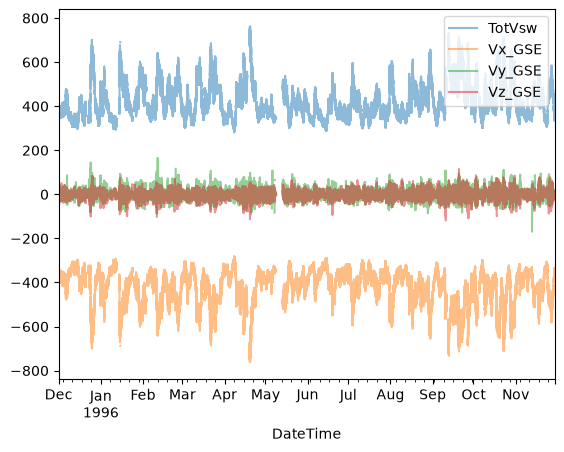

In [49]:
dataTSC23Min = AddTotVsw(dataTSC23Min)
PlotVsw(dataTSC23Min)
print(np.sort(dataTSC23Min._data["Vx_GSE"].unique()))
# print(dataTSC23Min._data["TotVsw"].unique())


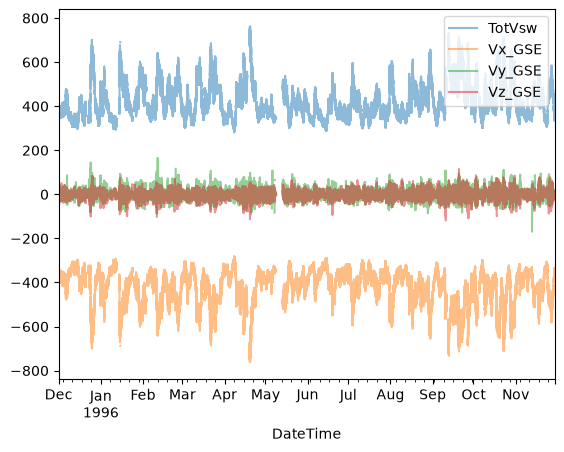

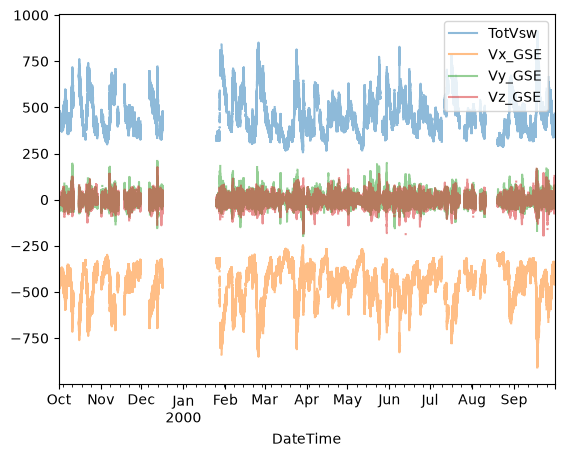

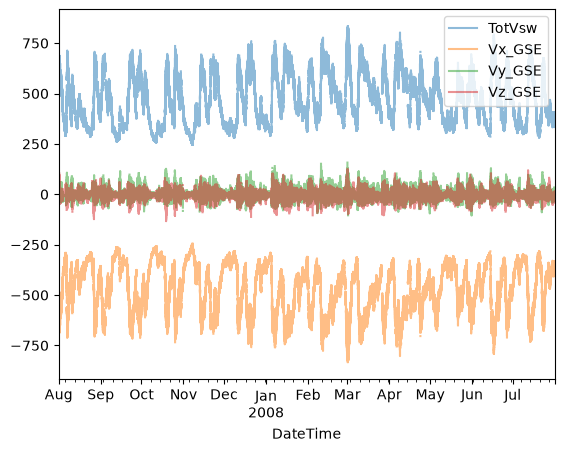

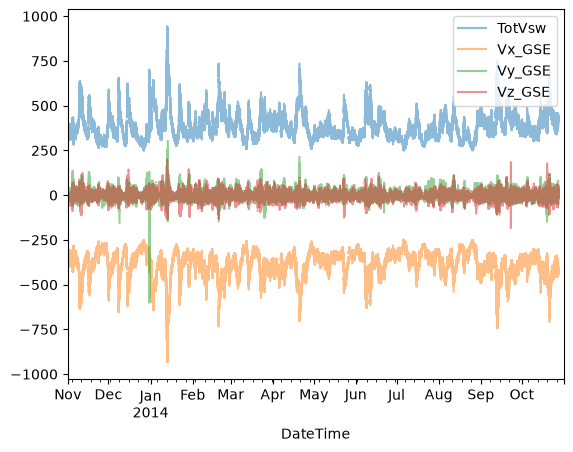

In [51]:
PlotVsw(dataTSC23Min)
PlotVsw(dataTSC23Max)
PlotVsw(dataTSC24Min)
PlotVsw(dataTSC24Max)

## BMag calculated

In [53]:
# Get BMag and plot data to check by eye if it's what you expect
dataTSC23Min = AddBMag(dataTSC23Min)
dataTSC23Max = AddBMag(dataTSC23Max)
dataTSC24Min = AddBMag(dataTSC24Min)
dataTSC24Max = AddBMag(dataTSC24Max)

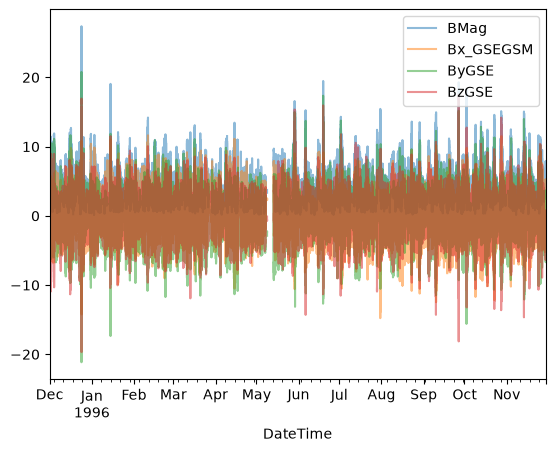

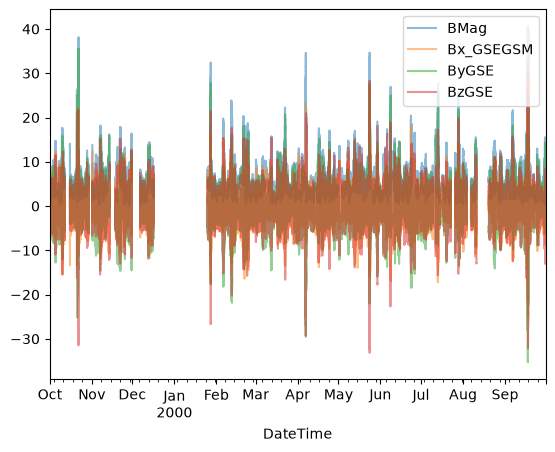

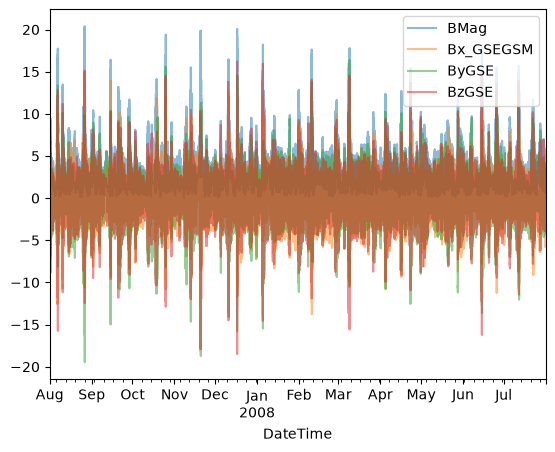

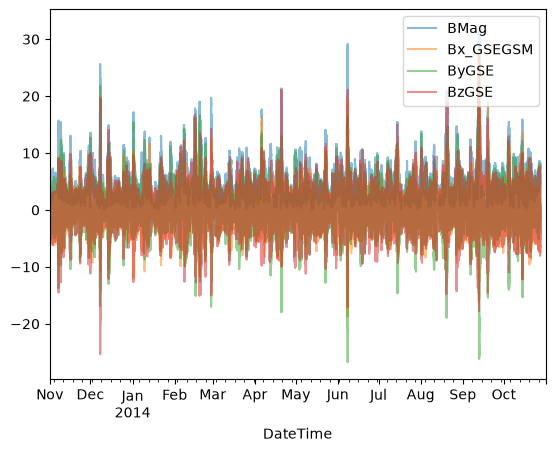

In [54]:
PlotB(dataTSC23Min)
PlotB(dataTSC23Max)
PlotB(dataTSC24Min)
PlotB(dataTSC24Max)

# print(np.sort(dataTSC23Min._data["Bx_GSEGSM"].unique()))

## Dotted plots for extra checks

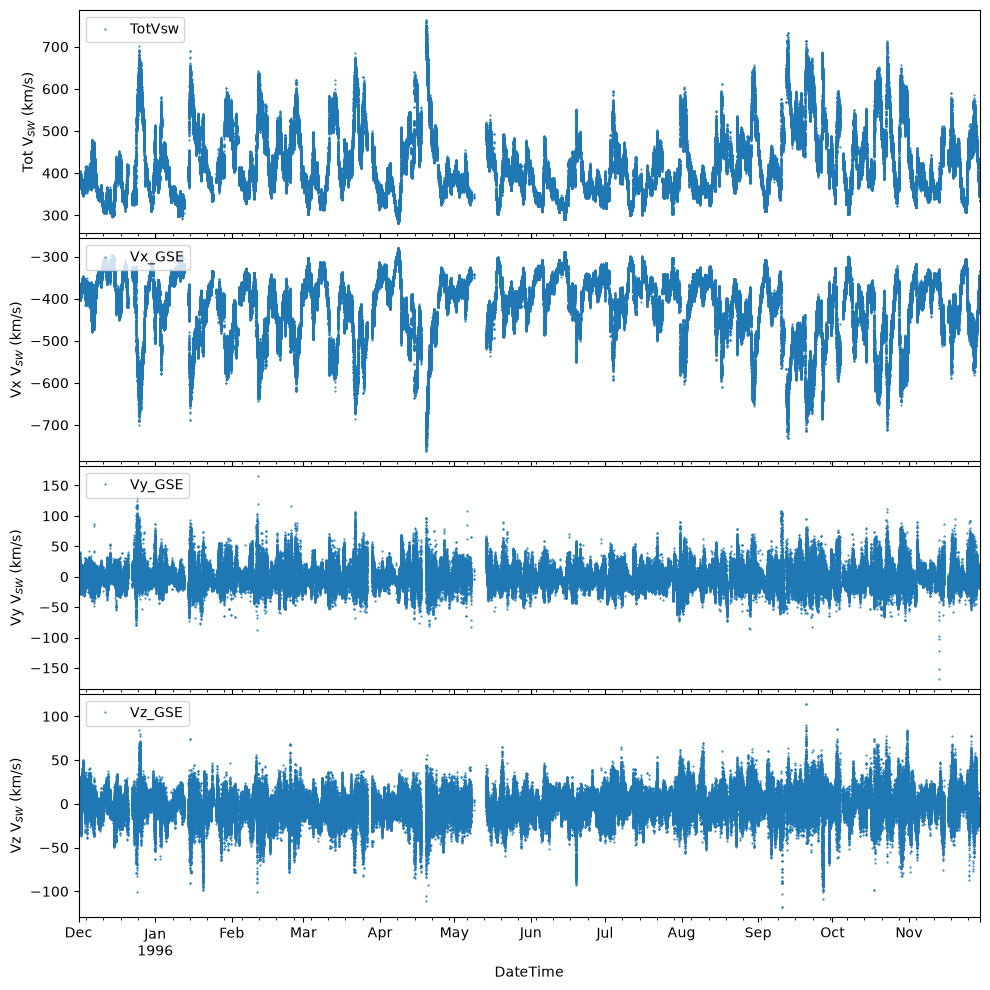

In [55]:
PlotVswDotted(dataTSC23Min)

## Histograms

### All together histograms

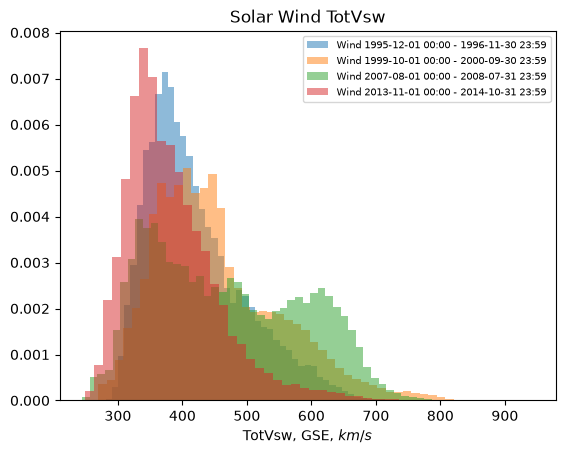

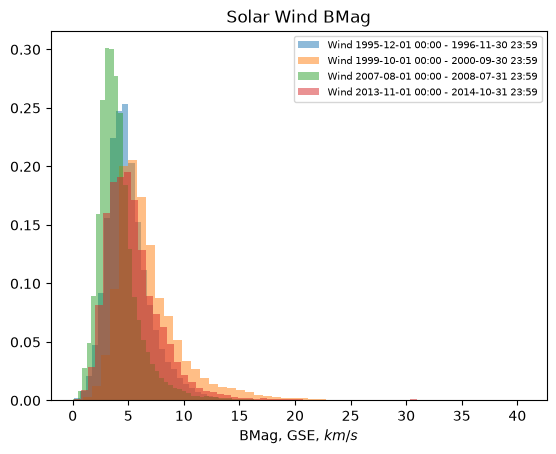

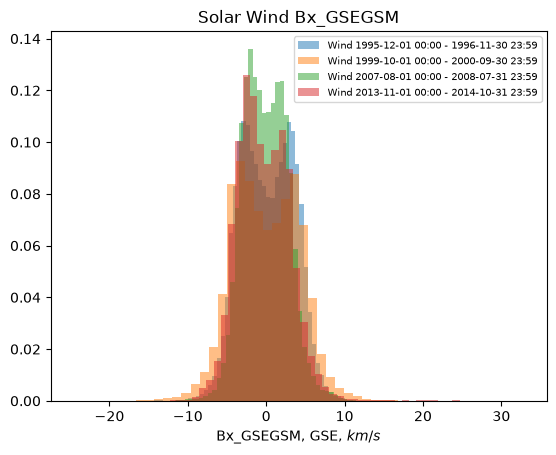

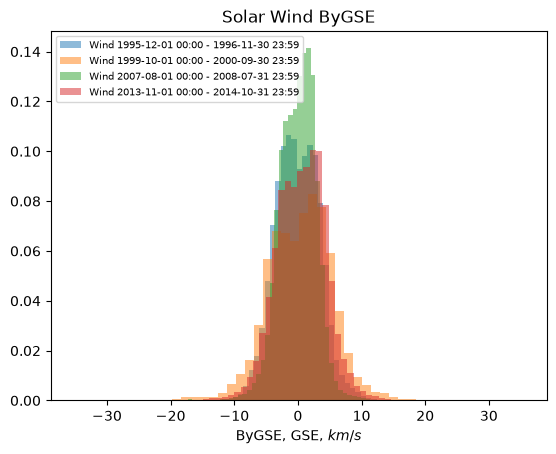

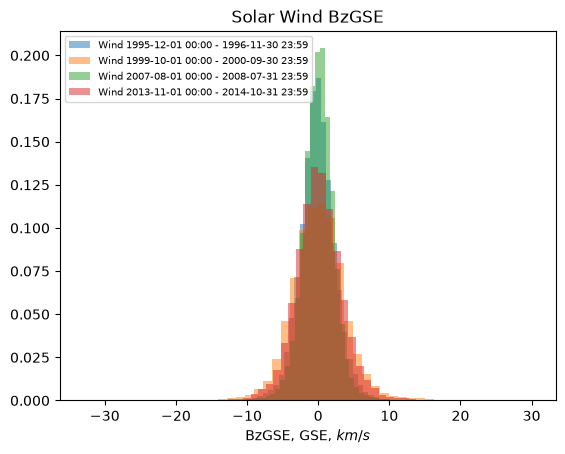

In [56]:
# Histogram formatting - all together
Bin = 50
Alpha = 0.5
Legend = 7.5
Plotting = ["TotVsw", "BMag", "Bx_GSEGSM", "ByGSE", "BzGSE"]
# Plotting = ["TotVsw", "BMag", "ScalarB", "Bx_GSEGSM", "ByGSE", "BzGSE"]

dataTimeSerieses = [dataTSC23Min, dataTSC23Max, dataTSC24Min, dataTSC24Max]
StartAndEnd = [[startDateC23Min, endDateC23Min], [startDateC23Max, endDateC23Max], [startDateC24Min, endDateC24Min], [startDateC24Max, endDateC24Max]]

PlotHistTogether(dataTimeSerieses, Plotting)

### Separate histograms

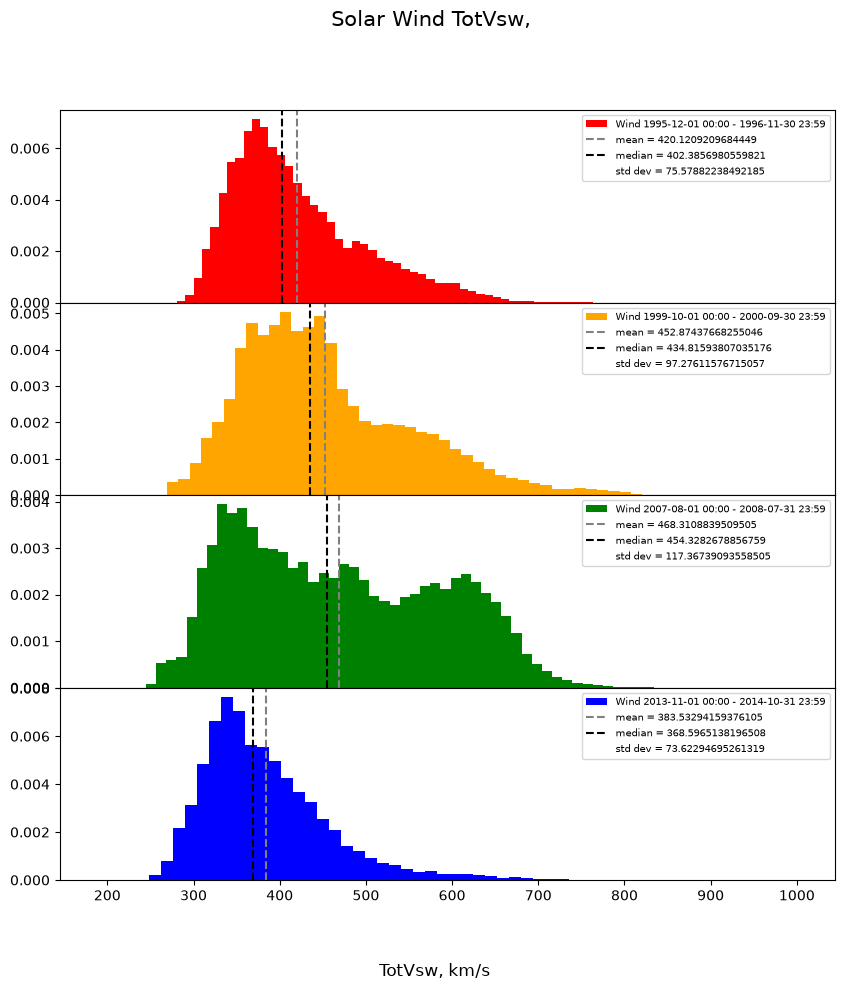

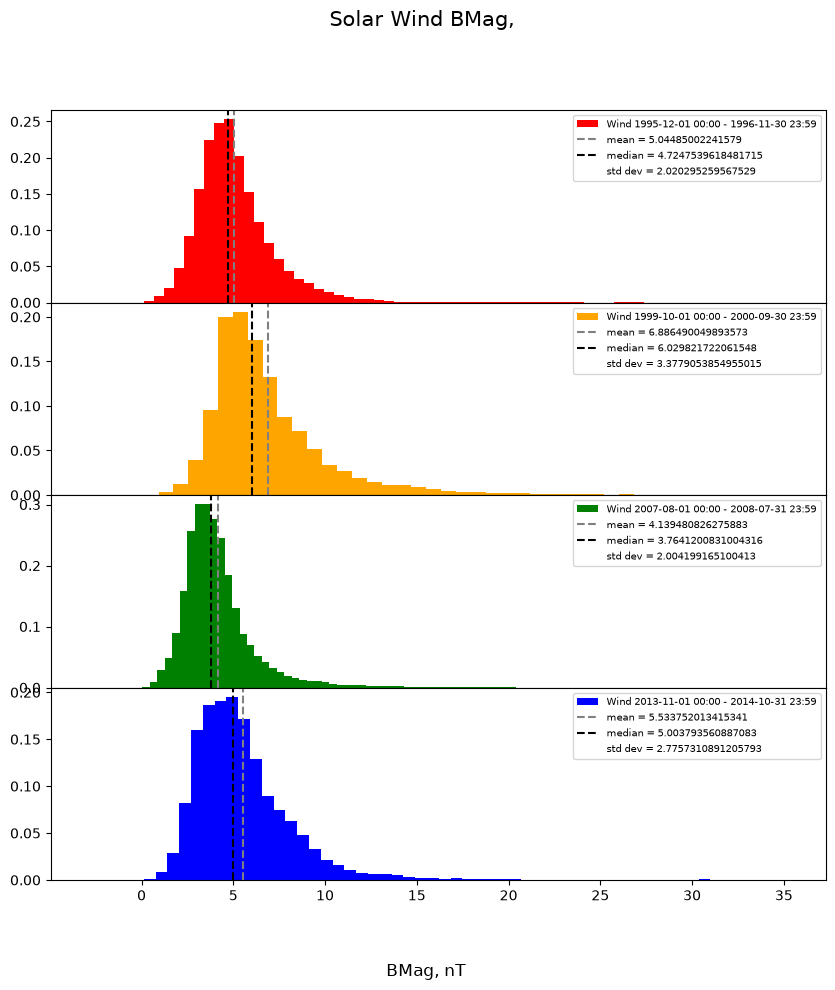

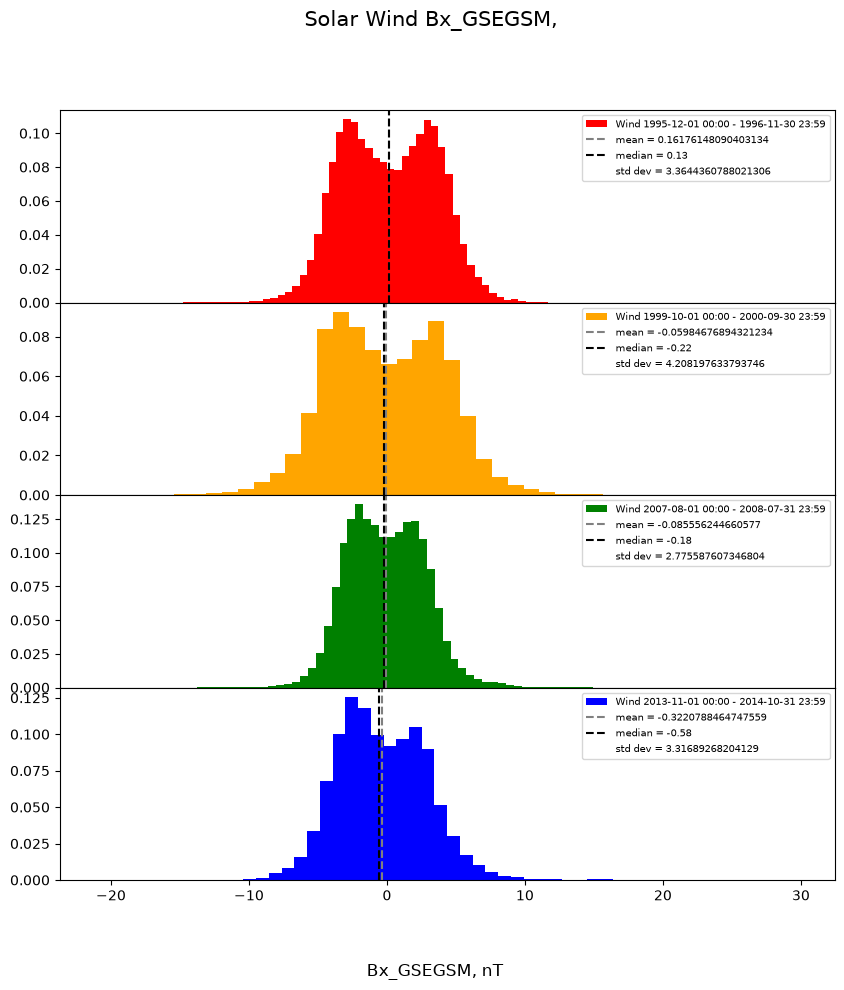

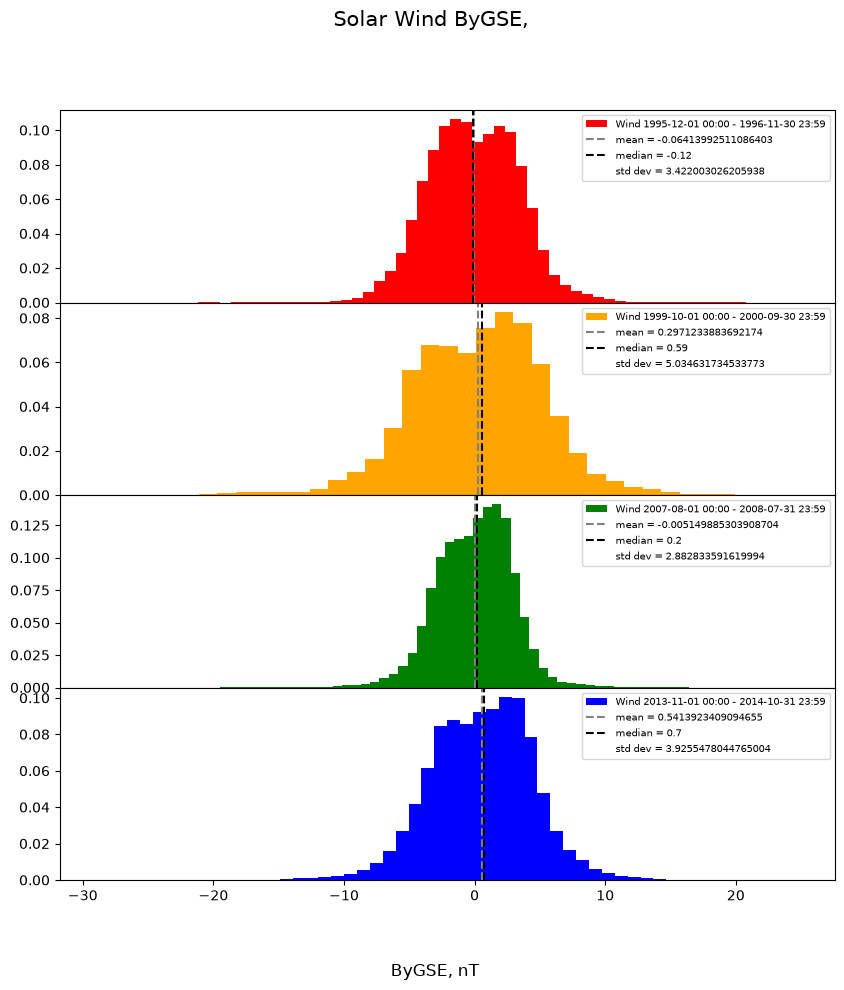

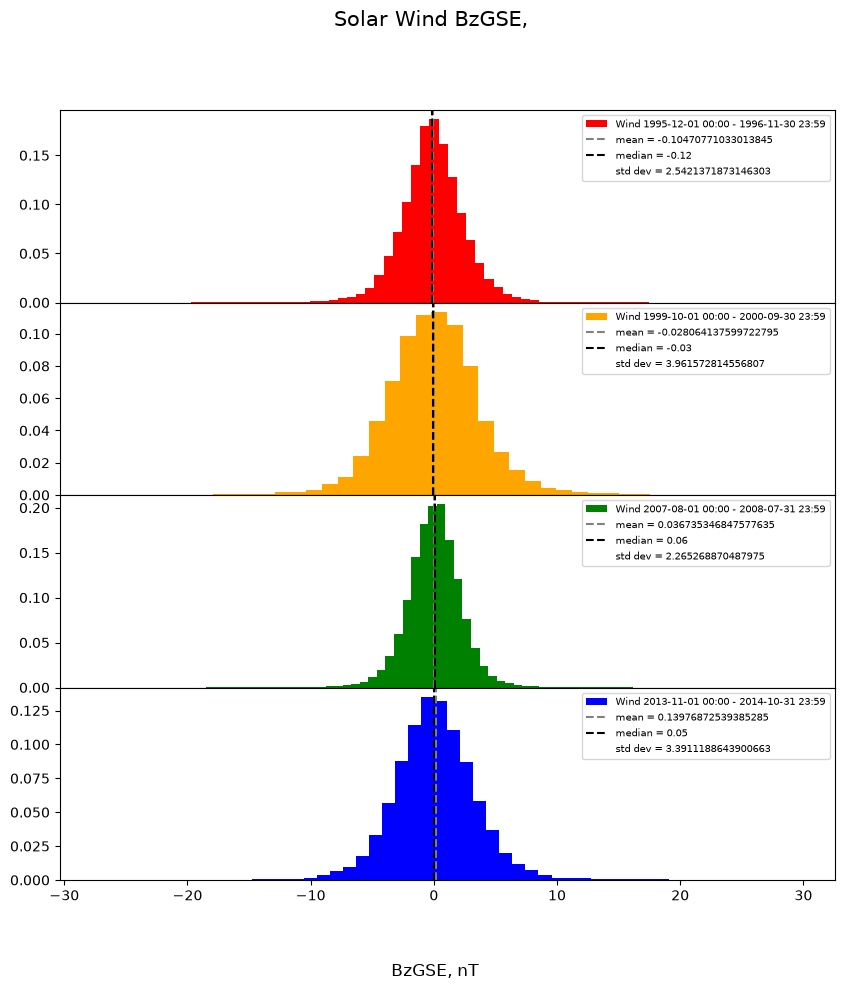

In [60]:
# Histogram formatting - Separate
Bin = 50
Alpha = 1
SupTitle = 15
Legend = 7.5
FigSize = (10,10)
LegLoc = 'upper right'
SpaceLR = [100, 5, 5, 5, 5]
Colours = ["red", "orange", "green", "blue"]
# dataTimeSerieses = [dataTSFirstDatesC23Min, dataTSFirstDatesC23Max, dataTSFirstDatesC24Min, dataTSFirstDatesC24Max]
dataTimeSerieses = [dataTSC23Min, dataTSC23Max, dataTSC24Min, dataTSC24Max]
Plotting = ["TotVsw", "BMag", "Bx_GSEGSM", "ByGSE", "BzGSE"]
# Plotting = ["FlowSpeed", "ScalarB", "Bx_GSEGSM", "ByGSE", "BzGSE"]
Units = ["km/s", "nT", "nT", "nT", "nT", "nT"]
# StartAndEnd = [[startDateC23Min, endDateC23Min], [startDateC23Max, endDateC23Max], [startDateC24Min, endDateC24Min], [startDateC23Max, endDateC23Max]]

# PlotHistSeparate(dataTimeSerieses, Plotting)

PlotHistSeparate(dataTimeSerieses, Plotting)

## CDFs

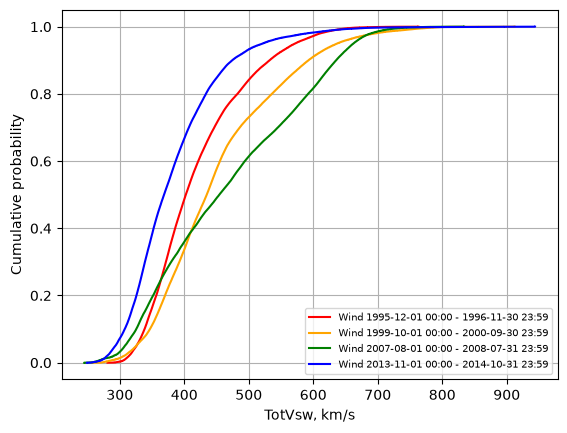

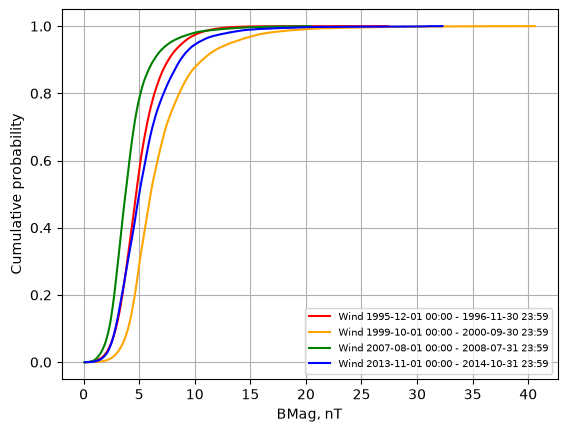

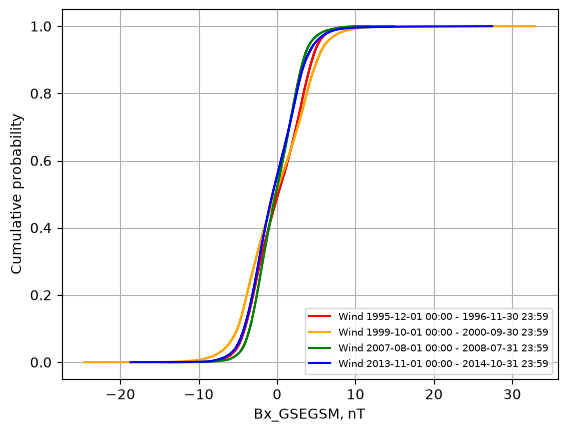

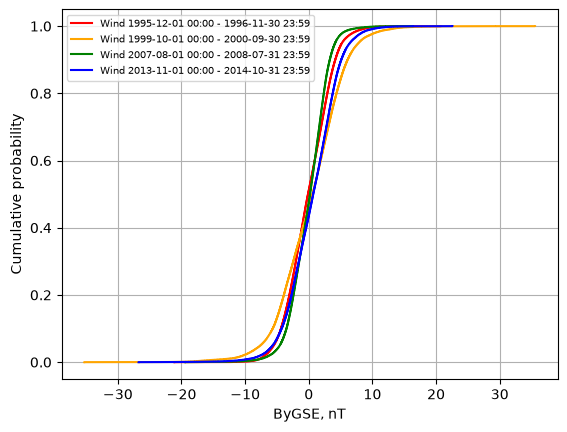

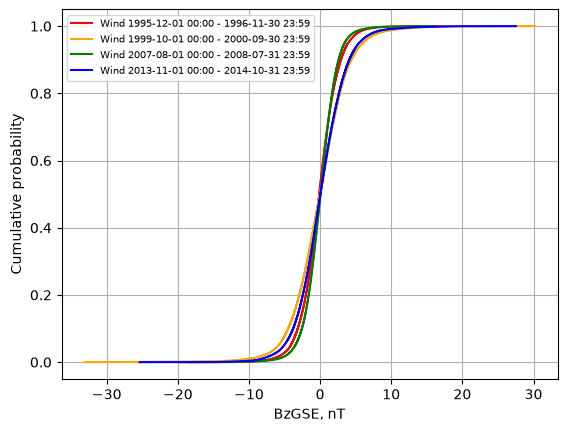

In [62]:
# CDF Formatting
yLim = [-0.05,1.05]
Legend = 7.5
Plotting = ["TotVsw", "BMag", "Bx_GSEGSM", "ByGSE", "BzGSE"]
# Plotting = ["FlowSpeed", "ScalarB", "Bx_GSEGSM", "ByGSE", "BzGSE"]
Unit = ["km/s", "nT", "nT", "nT", "nT"] #, "nT"]

# PlotCDF(dataTimeSerieses, Plotting)
PlotCDF(dataTimeSerieses, Plotting)

## Plotting DQQ and finding q values

### Plotting

5000 5000
286.35635482533354 269.10416957223964
(array([0]),) (array([0]),)
0.0002
0.0002
5000 5000
592.1695273102494 433.6525452479208
(array([4002]),) (array([4002]),)
0.8006
0.8006


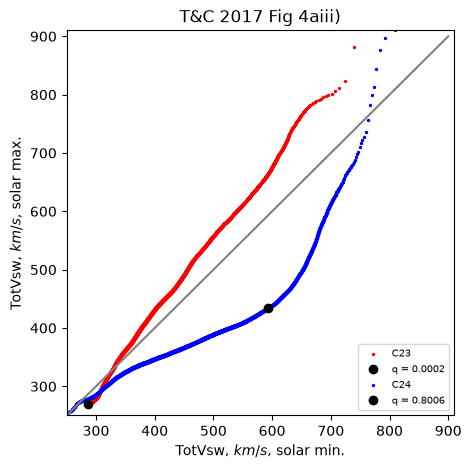

5000 5000
4.828136286394575 6.174320126132712
(array([2634]),) (array([2634]),)
0.527
0.527
5000 5000
0.35527985729329137 0.5833370815960293
(array([1]),) (array([1]),)
0.0004
0.0004


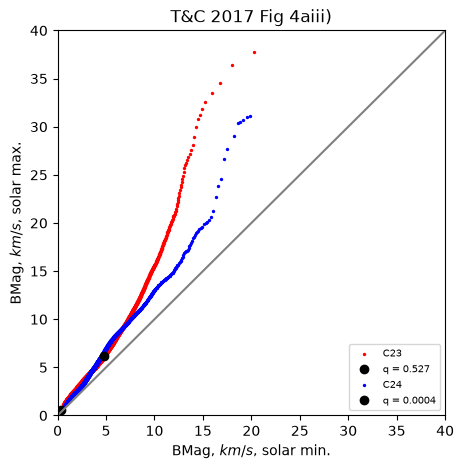

5000 5000
8.58 12.4
(array([1436]),) (array([1738]),)
Indexes don't match
1436 1738
8.58
12.4
XRes -1
8.49
YRes -1
12.2
---------------------------
Error finding breakpoints q
---------------------------
5000 5000
6.9 7.83
(array([1226]),) (array([1410]),)
Indexes don't match
1226 1410
6.9
7.83
XRes -1
6.86
YRes -1
7.79
---------------------------
Error finding breakpoints q
---------------------------


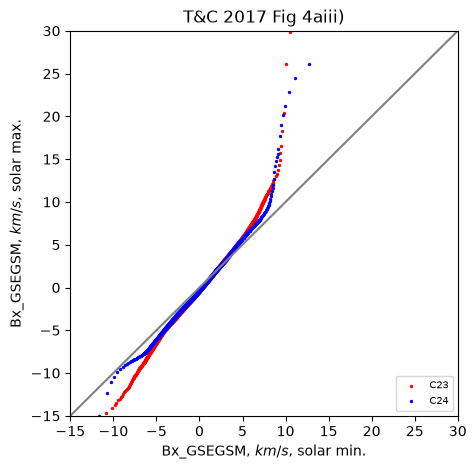

5000 5000
-11.114562999999999 -20.08
(array([4]),) (array([4]),)
0.001
0.001
5000 5000
11.865310000000171 15.38
(array([1326]),) (array([1710]),)
Indexes don't match
1326 1710
11.865310000000171
15.38
XRes -1
11.34
YRes -1
14.524638000000268
---------------------------
Error finding breakpoints q
---------------------------


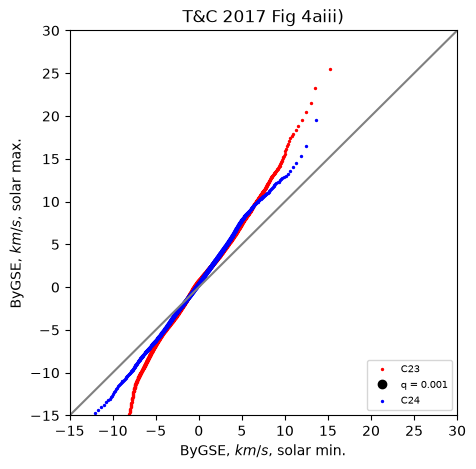

5000 5000
14.911502999999794 27.116280000000263
(array([1269]),) (array([1693]),)
Indexes don't match
1269 1693
14.911502999999794
27.116280000000263
XRes -1
13.2760120000015
YRes -1
23.901630000000587
---------------------------
Error finding breakpoints q
---------------------------
5000 5000
13.029174000000348 18.54
(array([1133]),) (array([1561]),)
Indexes don't match
1133 1561
13.029174000000348
18.54
XRes -1
12.415290000000386
YRes -1
18.26
---------------------------
Error finding breakpoints q
---------------------------


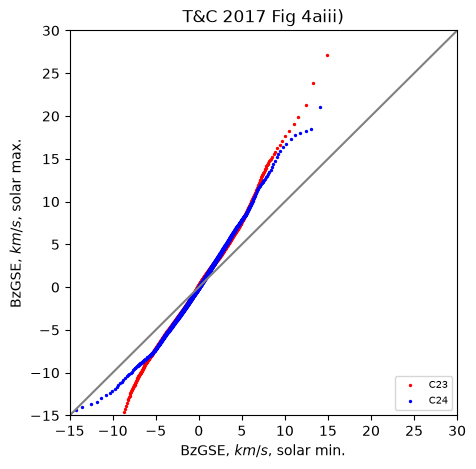

In [63]:
Plotting = ["TotVsw", "BMag", "Bx_GSEGSM", "ByGSE", "BzGSE"]
# Plotting = ["FlowSpeed", "ScalarB", "Bx_GSEGSM", "ByGSE", "BzGSE"]
Lims = [[250, 910], [0, 40], [-15, 30], [-15, 30], [-15, 30]]
Unit = ["km/s", "nT", "nT", "nT", "nT"] #, "nT"]

# Plotting = ["TotVsw", "BMag", "BX_GSE"]#, "BY_GSM", "BZ_GSM"]
# Lims = [[250, 910], [0, 40], [-15, 30]]#, [-15, 30], [-15, 30]]
Breakpoints = [ [[ 0.9960, 0.9995], [ 0.8660, 0.9980]], [[ 0.9990, 0.9750], [ 0.9990, 0.9970]], [[ 0.9980, 0.1100], [ 0.9980, 0.1100]]]
dataTimeSeriesToCompare = [ [dataTSC23Min, dataTSC23Max], [dataTSC24Min, dataTSC24Max]]
PlotLabels = ["C23", "C24"]
Color = ["red", "blue"]

PlotDQQ(dataTimeSeriesToCompare, Plotting, Breakpoints)

# Separated Fast and Slow Wind

DateTime
1995-12-01 00:00:00    404.291096
1995-12-01 00:01:00    401.058437
1995-12-01 00:02:00    396.178255
1995-12-01 00:03:00    394.367113
1995-12-01 00:04:00    394.557702
                          ...    
1996-11-29 18:45:00    375.444190
1996-11-29 18:46:00    375.600985
1996-11-29 18:47:00    375.592199
1996-11-29 18:48:00    375.255460
1996-11-29 18:49:00           NaN
Name: TotVsw, Length: 525290, dtype: float64


KeyError: 0

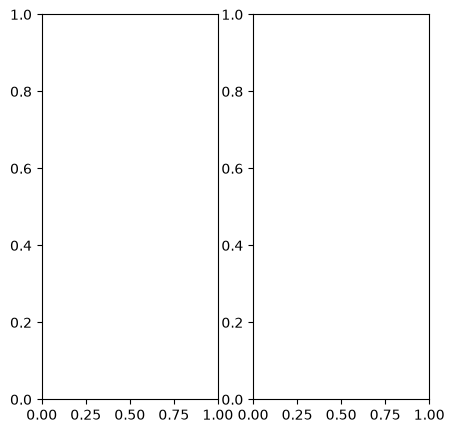

In [64]:
# print(dataTimeSeriesToCompare)

#Plot DQQ graphs with qs
def PlotDQQSplittingFastAndSlow(dataTimeSeriesToCompare, VarsToPlot, QuantilesSpecific, SplitValue):
    for i in range(len(VarsToPlot)): # do each parameter
        fig, ax  = plt.subplots(1,2, figsize=(5, 5))
        for j in range(len(dataTimeSeriesToCompare)): # do each comparison
            dataTimeSeriesPS1 = pl.Series(dataTimeSeriesToCompare[j][0]._data[VarsToPlot[i]])
            dataTimeSeriesPS2 = pl.Series(dataTimeSeriesToCompare[j][1]._data[VarsToPlot[i]])

            print(dataTimeSeriesToCompare[j][0]._data[VarsToPlot[i]])

            # s = pl.Series("a", [1, 2, 3])
            MaskingBelow = []
            MaskingAbove = []
            for m in range(len(dataTimeSeriesPS1)):
                if dataTimeSeriesToCompare[j][0]._data[VarsToPlot[i]][m] < SplitValue:
                    MaskingBelow.append(True)
                    MaskingAbove.append(False)
                else:
                    MaskingBelow.append(False)
                    MaskingAbove.append(True)

            maskBelow = pl.Series("", MaskingBelow)
            maskAbove = pl.Series("", MaskingAbove)

            dataTimeSeriesPS1Below = dataTimeSeriesPS1.filter(maskBelow)
            dataTimeSeriesPS1Above = dataTimeSeriesPS1.filter(maskAbove)  

            xQuantBelow, yQuantBelow = get_quantiles(dataTimeSeriesPS1Below, dataTimeSeriesPS2Below, size = 5000, p_range=(0.0001, 0.9999))
            axs[0].scatter(xQuantBelow, yQuantBelow, color=Color[j], s=2, label = PlotLabels[j])
            xQuantAbove, yQuantAbove = get_quantiles(dataTimeSeriesPS1Above, dataTimeSeriesPS2Above, size = 5000, p_range=(0.0001, 0.9999))
            axs[1].scatter(xQuantAbove, yQuantAbove, color=Color[j], s=2, label = PlotLabels[j])

            xOfKneeBelow, yOfKneeBelow, quantOfKneeBelow = FindQuantOfKnee(xQuantBelow, yQuantBelow)
            xOfKneeAbove, yOfKneeAbove, quantOfKneeAbove = FindQuantOfKnee(xQuantAbove, yQuantAbove)

            if np.isnan(quantOfKneeBelow):
                print("---------------------------")
                print("Error finding breakpoints q")
                print("---------------------------")
            else:
                plt.plot(xOfKneeBelow, yOfKneeBelow, "o", color="black", label = "q = " + str(quantOfKneeBelow))
                # plt.plot(xOfKneeBelow, yOfKneeBelow, "o", color="black")

            if np.isnan(quantOfKneeAbove):
                print("---------------------------")
                print("Error finding breakpoints q")
                print("---------------------------")
            else:
                plt.plot(xOfKneeAbove, yOfKneeAbove, "o", color="black", label = "q = " + str(quantOfKneeAbove))
                # plt.plot(xOfKneeAbove, yOfKneeAbove, "o", color="black")


            # xQuantBelow, yQuantBelow = get_quantiles(dataTimeSeriesPS1Below, dataTimeSeriesPS2Below, size = 5000, p_range=(0.0001, 0.9999))
            # plt.scatter(xQuantBelow, yQuantBelow, color=Color[j], s=2, label = PlotLabels[j])
            # xQuantAbove, yQuantAbove = get_quantiles(dataTimeSeriesPS1Above, dataTimeSeriesPS2Above, size = 5000, p_range=(0.0001, 0.9999))
            # plt.scatter(xQuantAbove, yQuantAbove, color=Color[j], s=2, label = PlotLabels[j])
            
            # xOfKneeBelow, yOfKneeBelow, quantOfKneeBelow = FindQuantOfKnee(xQuantBelow, yQuantBelow)
            # xOfKneeAbove, yOfKneeAbove, quantOfKneeAbove = FindQuantOfKnee(xQuantAbove, yQuantAbove)
            
            # if np.isnan(quantOfKnee):
            #     print("---------------------------")
            #     print("Error finding breakpoints q")
            #     print("---------------------------")
            # else:
            #     plt.plot(xOfKnee, yOfKnee, "o", color="black", label = "q = " + str(quantOfKnee))
            #     # plt.plot(xOfKnee, yOfKnee, "o", color="black")
        
        x = np.linspace(-100, 900, 2)
        y = x

        for aa in ax:
            aa.plot(x, y, color="grey")
            aa.legend(loc="lower right", fontsize = Legend)
            aa.xlabel(VarsToPlot[i] + r", $km/s$, solar min.")
            aa.ylabel(VarsToPlot[i] + r", $km/s$, solar max.")
            aa.set_xlim(Lims[i])
            aa.set_ylim(Lims[i])
        
        ax[0].savefig("DQQBelow_Wind.png")
        ax[1].savefig("DQQAbove_Wind.png")

        plt.show()

        # C23
        # data_sortedPLSeriesXC23 = pl.Series(dataTimeSerieses[j]._data[VarsToPlot[i]]) # make data into a polar series
        # data_sortedPLSeriesYC23 = pl.Series(dataTimeSerieses[j]._data[VarsToPlot[i]])

PlotDQQSplittingFastAndSlow(dataTimeSeriesToCompare, Plotting, Breakpoints, 450)

# Archived code

In [65]:
# def PlotVswFiltered(dataTimeSeries, filter):
#     Filtered = dataTimeSeries._data[dataTimeSeries._data['TotVsw'] < filter]
#     FilteredTS = dfToSeries(Filtered)
#     # print(FilteredTS)
#     fig, ax = plt.subplots()
#     FilteredTS.plot(columns=["TotVsw", "FlowSpeed", "Vx_GSE", "Vy_GSE", "Vz_GSE"], alpha = 0.5)
#     plt.legend(loc="upper right")
#     # plt.ylim(-450,900)

# PlotVswFiltered(dataTSC23Min, 10000)
# PlotVswFiltered(dataTSC23Max, 10000)
# PlotVswFiltered(dataTSC24Min, 10000)
# PlotVswFiltered(dataTSC24Max, 10000)

In [66]:
# def PlotVswRemoveFiller(dataTimeSeries):
#     cols = ["FlowSpeed", "Vx_GSE", "Vy_GSE", "Vz_GSE"]
#     fig, ax = plt.subplots()
#     for i in range(len(cols)):
#         Filtered = dataTimeSeries._data[dataTimeSeries._data[cols[i]] != 99999.9]
#         FilteredTS = dfToSeries(Filtered)
#         # print(FilteredTS)
#         FilteredTS.plot(columns=[cols[i]], alpha = 0.5)

#     plt.legend(loc="upper right")
#     plt.title(dataTimeSeries.time_range)
#     # plt.ylim(-450,900)

# def PlotBRemoveFiller(dataTimeSeries):
#     cols = ["ScalarB", "Bx_GSEGSM", "ByGSE", "BzGSE"]
#     fig, ax = plt.subplots()
#     for i in range(len(cols)):
#         Filtered = dataTimeSeries._data[dataTimeSeries._data[cols[i]] != 9999.99]
#         FilteredTS = dfToSeries(Filtered)
#         # print(FilteredTS)
#         FilteredTS.plot(columns=[cols[i]], alpha = 0.5)

#     plt.legend(loc="upper right")
#     plt.title(dataTimeSeries.time_range)
#     # plt.ylim(-40,90)

# # Plot histograms all together
# def PlotHistTogetherRemoveFiller(dataTimeSerieses, VarsToPlot, Fillers):
#     for i in range(len(VarsToPlot)):
#         for j in range(len(dataTimeSerieses)):
#             Filtered = dataTimeSerieses[j]._data[dataTimeSerieses[j]._data[VarsToPlot[i]] != Fillers[i]]
#             FilteredTS = dfToSeries(Filtered)
#             plt.hist(FilteredTS._data[VarsToPlot[i]], bins = Bin, label = "Wind " + str(StartAndEnd[j][0] + " - " + str(StartAndEnd[j][1])), alpha = Alpha, density = True)
#         plt.title("Solar Wind " + VarsToPlot[i])
#         plt.xlabel(VarsToPlot[i] + r", GSE, $km/s$")
#         plt.legend(fontsize=Legend)
#         plt.show()

# #Plot histograms separately
# def PlotHistSeparateRemoveFillers(dataTimeSerieses, VarsToPlot, Fillers):
#     for i in range(len(VarsToPlot)): # For each variable
#         LowerBounds = [] # set lower bounds array to 0
#         UpperBounds = [] # set upper bounds array to 0
#         fig, axs = plt.subplots(4,1, figsize=FigSize, sharex=True)
#         fig.subplots_adjust(hspace=0)
#         for j in range(len(dataTimeSerieses)): # For each daterange
#             Filtered = dataTimeSerieses[j]._data[dataTimeSerieses[j]._data[VarsToPlot[i]] != Fillers[i]]
#             FilteredTS = dfToSeries(Filtered)
#             axs[j].hist(FilteredTS._data[VarsToPlot[i]], bins = Bin, label = "Wind " + str(StartAndEnd[j][0]) + " - " + str(StartAndEnd[j][1]), color=Colours[j], alpha = Alpha, density = True)
#             #Mean
#             axs[j].axvline(FilteredTS._data[VarsToPlot[i]].mean(), linestyle = '--', color = "grey", label="mean = " + str(FilteredTS._data[VarsToPlot[i]].mean()))
#             #Median
#             axs[j].axvline(FilteredTS._data[VarsToPlot[i]].median(), linestyle = '--', color = "black", label="median = " + str(FilteredTS._data[VarsToPlot[i]].median()))
#             #Standard deviation
#             axs[j].axvline(FilteredTS._data[VarsToPlot[i]].std(), color = "grey", label="std dev = " + str(FilteredTS._data[VarsToPlot[i]].std()), alpha = 0)

#             axs[j].legend(loc = LegLoc, fontsize = Legend)
#                 # axs[1].legend(loc = LegLoc, fontsize = Legend)
#                 # axs[2].legend(loc = LegLoc, fontsize = Legend)
#                 # axs[3].legend(loc = LegLoc, fontsize = Legend)
            
#             LowerBounds.append(min(FilteredTS._data[VarsToPlot[i]].values))
#             UpperBounds.append(max(FilteredTS._data[VarsToPlot[i]].values))
#             # LowerBounds.append(min(dataTimeSerieses[j]._data[Plotting[i]].values))
#             # UpperBounds.append(max(dataTimeSerieses[j]._data[Plotting[i]].values))
#             # LowerBounds.append(min(dataTimeSerieses[j]._data[Plotting[i]].values))
#             # UpperBounds.append(max(dataTimeSerieses[j]._data[Plotting[i]].values))
#             # LowerBounds.append(min(dataTimeSerieses[j]._data[Plotting[i]].values))
#             # UpperBounds.append(max(dataTimeSerieses[j]._data[Plotting[i]].values))
        
#         plt.suptitle("Solar Wind "+ VarsToPlot[i] + ", ", fontsize = SupTitle)
#         fig.supxlabel(VarsToPlot[i] + ", " + str(Units[i]))

#         plt.xlim(min(LowerBounds) - SpaceLR[i], max(UpperBounds) + SpaceLR[i])
#         plt.savefig("Plots/Wind/" + StartAndEnd[0][0][0:10] + "->" + StartAndEnd[0][0][0:10] + VarsToPlot[i] + "_Wind.png")
#         # plt.show()

# Plot CDF
# def PlotCDFRemoveFillers(dataTimeSerieses, VarsToPlot, Fillers):
#     # fig, axs = plt.subplots()#4,1, figsize=FigSize, sharex=True)
#     # fig.subplots_adjust(hspace=0)
#     for i in range(len(VarsToPlot)):
#         for j in range(len(dataTimeSerieses)):
#             Filtered = dataTimeSerieses[j]._data[dataTimeSerieses[j]._data[VarsToPlot[i]] != Fillers[i]]
#             FilteredTS = dfToSeries(Filtered)
#             sns.ecdfplot(FilteredTS._data[VarsToPlot[i]], label="Wind " + str(StartAndEnd[j][0]) + " - " + str(StartAndEnd[j][1]), color=Colours[j])
#         plt.xlabel(VarsToPlot[i] + ", " + Units[i])
#         plt.ylabel('Cumulative probability')
#         plt.ylim(yLim)
#         plt.legend(fontsize=Legend)
#         plt.grid(True)
#         plt.savefig("Plots/Wind/" + StartAndEnd[0][0][0:10] + "->" + StartAndEnd[0][0][0:10] + VarsToPlot[i] + "_CDF_Wind.png") #  + dataTimeSerieses[0] + " - " + dataTimeSerieses[-1] 
#         plt.show()

# def PlotDQQRemoveFillers(dataTimeSeriesToCompare, VarsToPlot, QuantilesSpecific, Fillers):
#     for i in range(len(VarsToPlot)): # do each parameter
#         fig, ax  = plt.subplots(figsize=(5, 5))
#         for j in range(len(dataTimeSeriesToCompare)): # do each comparison
#             Filtered1 = dataTimeSeriesToCompare[j][0]._data[dataTimeSeriesToCompare[j][0]._data[VarsToPlot[i]] != Fillers[i]]
#             FilteredTS1 = dfToSeries(Filtered1)
#             Filtered2 = dataTimeSeriesToCompare[j][1]._data[dataTimeSeriesToCompare[j][1]._data[VarsToPlot[i]] != Fillers[i]]
#             FilteredTS2 = dfToSeries(Filtered2)
#             dataTimeSeriesPS1 = pl.Series(FilteredTS1._data[VarsToPlot[i]])
#             dataTimeSeriesPS2 = pl.Series(FilteredTS2._data[VarsToPlot[i]])
#             xQuant, yQuant = get_quantiles(dataTimeSeriesPS1, dataTimeSeriesPS2, size = 5000, p_range=(0.0001, 0.9999))
#             plt.scatter(xQuant, yQuant, color=Color[j], s=2, label = PlotLabels[j])

#             xOfKnee, yOfKnee, quantOfKnee = FindQuantOfKnee(xQuant, yQuant)

#             if np.isnan(quantOfKnee):
#                 print("---------------------------")
#                 print("Error finding breakpoints q")
#                 print("---------------------------")
#             else:
#                 plt.plot(xOfKnee, yOfKnee, "o", color="black", label = "q = " + str(quantOfKnee))
#             # plt.plot(xOfKnee, yOfKnee, "o", color="black")
        
#         x = np.linspace(-100, 900, 2)
#         y = x
#         plt.plot(x, y, color="grey")
#         plt.title("T&C 2017 Fig 4aiii)")
#         plt.legend(loc="lower right", fontsize = Legend)
#         plt.xlabel(VarsToPlot[i] + r", $km/s$, solar min.")
#         plt.ylabel(VarsToPlot[i] + r", $km/s$, solar max.")
#         plt.xlim(Lims[i]) #min(xQuantC23)-np.absolute(min(xQuantC23)/2) , max(xQuantC23)+np.absolute(max(xQuantC23)/2))
#         plt.ylim(Lims[i]) #min(xQuantC23)-np.absolute(min(xQuantC23)/2), max(xQuantC23)+np.absolute(max(xQuantC23)/2))
#         plt.savefig("/Plots/Wind/DQQ_Wind" + VarsToPlot[i] + ".png")

#         plt.show()

# def PlotBFiltered(dataTimeSeries, filter):
#     Filtered = dataTimeSeries._data[dataTimeSeries._data['BMag'] < filter]
#     FilteredTS = dfToSeries(Filtered)
#     # print(FilteredTS)
#     fig, ax = plt.subplots()
#     FilteredTS.plot(columns=["BMag", "ScalarB"], alpha = 0.5) #, "Bx_GSEGSM", "ByGSE", "BzGSE"], alpha = 0.5)
#     plt.legend(loc="upper right")
#     # plt.ylim(-450,900)

# PlotBFiltered(dataTSC23Min, 1000)
# PlotBFiltered(dataTSC23Max, 1000)
# PlotBFiltered(dataTSC24Min, 1000)
# PlotBFiltered(dataTSC24Max, 1000)

# Testing BMag vs ScalarB

In [67]:
# #Straight differences
# differences = dataTSC23Min._data['BMag'] - dataTSC23Min._data['ScalarB']
# print(np.sort(differences.unique()))

# #Magnitudes of differences
# print(np.sort(np.abs(differences.unique())))

# #Top ten largest differences
# print(np.sort(np.abs(differences.unique()))[-10:])
